In [2]:
import numpy as np 
import pandas as pd 
import os
csv_path = 'netflix_titles.csv' if os.path.exists('netflix_titles.csv') else '../netflix_titles.csv'
df = pd.read_csv(csv_path)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
print(df.shape)

(8807, 12)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
# missing values analysis 
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [8]:
#   movie vs tv shows  
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [9]:
# Top 10 countries producing content (splitting comma-separated values)
countries = df['country'].dropna().str.split(', ').explode()
countries.value_counts().head(10)

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

In [10]:
# top ratings 
rating = df['rating'].value_counts()

In [30]:
df.sample(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,decade
7084,s7085,Movie,Instructions Not Included,Eugenio Derbez,"Eugenio Derbez, Jessica Lindsey, Loreto Peralt...",Mexico,"January 1, 2020",2013,PG-13,122 min,"Comedies, Dramas, International Movies",Unable to locate the elusive mother of a baby ...,2010
8534,s8535,Movie,The Tribes of Palos Verdes,"Brendan Malloy, Emmett Malloy","Jennifer Garner, Maika Monroe, Cody Fern, Just...",United States,"December 1, 2019",2017,R,104 min,"Dramas, Independent Movies, Sports Movies",When a move to an exclusive seaside community ...,2010
7666,s7667,TV Show,One Strange Rock,NaN,Will Smith,United States,"February 2, 2019",2018,TV-PG,1 Season,"Docuseries, Science & Nature TV","Hosted by Will Smith, this series follows eigh...",2010
986,s987,Movie,Kocan Kadar Konus 2: Dirilis,Kıvanç Baruönü,"Ezgi Mola, Murat Yıldırım, Gülenay Kalkan, Nev...",Turkey,"April 23, 2021",2016,TV-14,104 min,"Comedies, International Movies, Romantic Movies","Efsun has found Mr. Right in Sinan, and their ...",2010
8469,s8470,Movie,The Pursuit of Happyness,Gabriele Muccino,"Will Smith, Jaden Smith, Thandie Newton, Brian...",United States,"October 1, 2019",2006,PG-13,117 min,Dramas,"When Chris and his son are evicted, they face ...",2000


In [36]:
# Top 10 directors (splitting comma-separated values) explode - list new row convert 
directors = df['director'].dropna().str.split(', ').explode().str.strip()
directors

0       Kirsten Johnson
2       Julien Leclercq
5         Mike Flanagan
6         Robert Cullen
6        José Luis Ucha
             ...       
8801    Majid Al Ansari
8802      David Fincher
8804    Ruben Fleischer
8805       Peter Hewitt
8806        Mozez Singh
Name: director, Length: 6978, dtype: object

In [12]:
# release year trend
df['release_year'].value_counts().sort_index()

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

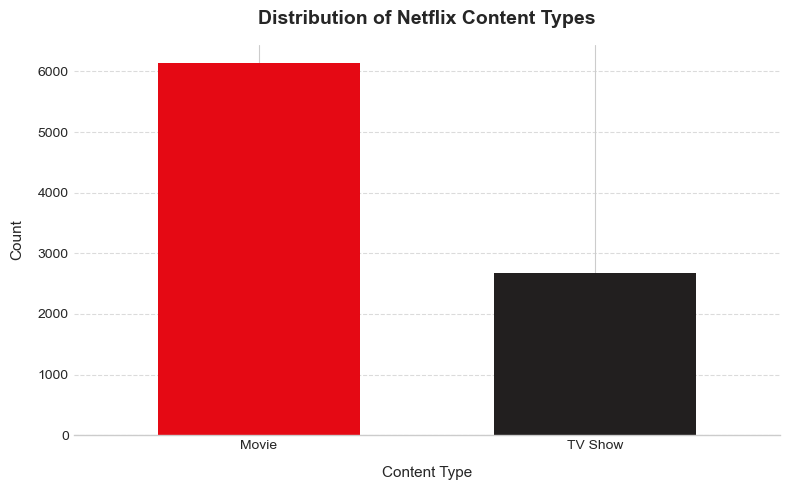

In [13]:
import matplotlib.pyplot as plt 
import os

# Clean plot settings
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(8, 5))

type_counts = df['type'].value_counts()
type_counts.plot(kind='bar', color=['#E50914', '#221F1F'], edgecolor='none', width=0.6, ax=ax)

ax.set_title("Distribution of Netflix Content Types", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Content Type", fontsize=11, labelpad=10)
ax.set_ylabel("Count", fontsize=11, labelpad=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.xticks(rotation=0)

plt.tight_layout()
path = 'python/Moviesvstv.png' if os.path.exists('python') else 'Moviesvstv.png'
plt.savefig(path, dpi=300, bbox_inches='tight')
plt.show()

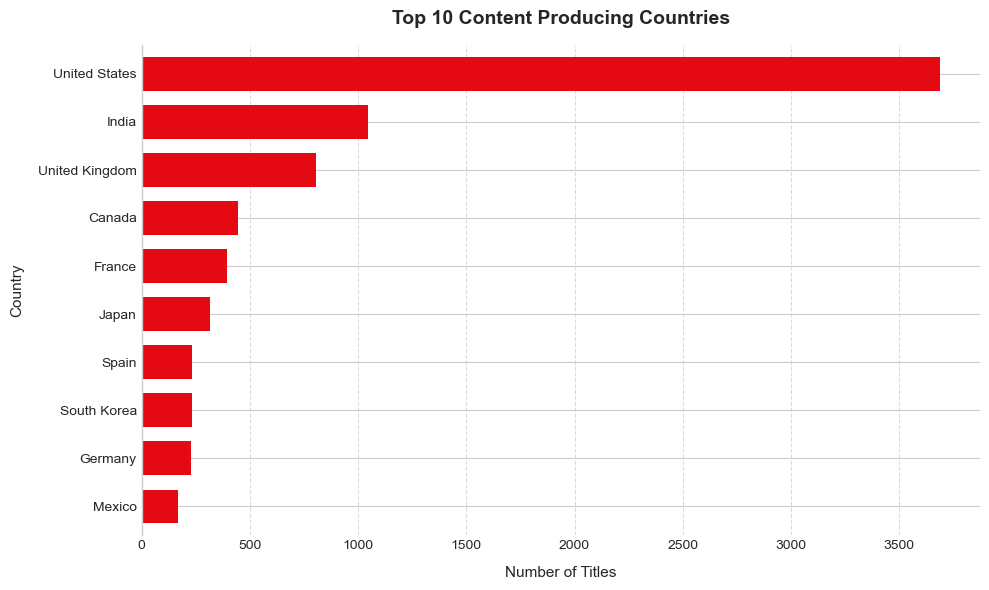

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

countries = df['country'].dropna().str.split(', ').explode()
top_countries = countries.value_counts().head(10).sort_values(ascending=True)

top_countries.plot(kind='barh', color='#E50914', width=0.7, ax=ax)

ax.set_title("Top 10 Content Producing Countries", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Number of Titles", fontsize=11, labelpad=10)
ax.set_ylabel("Country", fontsize=11, labelpad=10)
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.tight_layout()
plt.show()

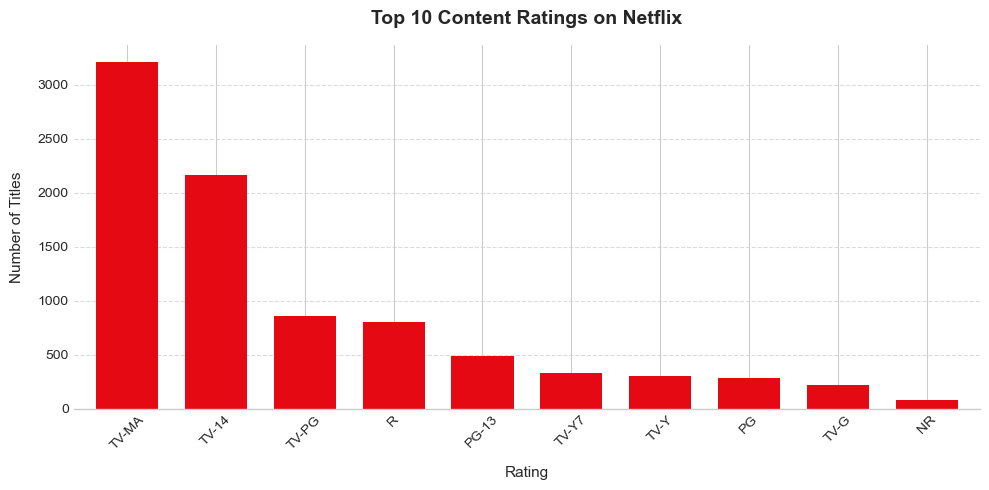

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

rating_counts = df['rating'].value_counts().head(10)
rating_counts.plot(kind='bar', color='#E50914', edgecolor='none', width=0.7, ax=ax)

ax.set_title("Top 10 Content Ratings on Netflix", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Rating", fontsize=11, labelpad=10)
ax.set_ylabel("Number of Titles", fontsize=11, labelpad=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

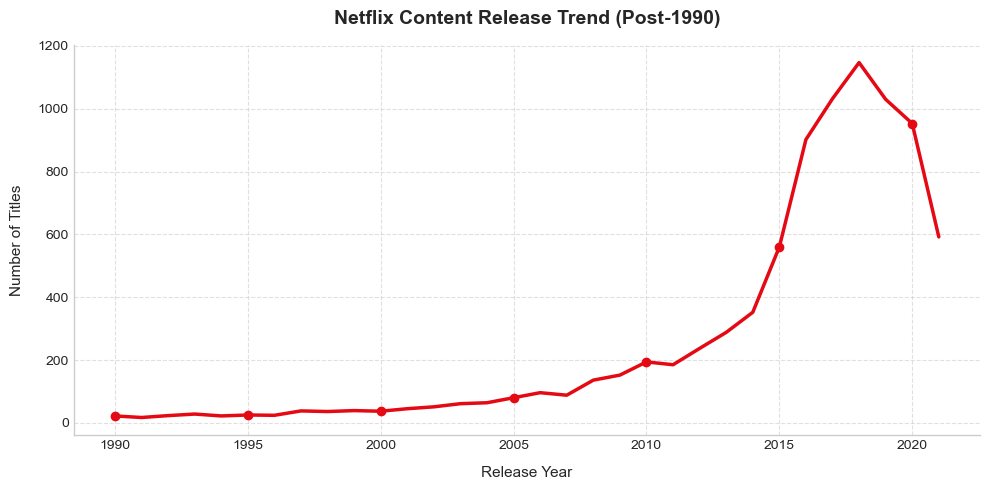

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

# Focus on years after 1990 for a cleaner trend line
year_trend = df[df['release_year'] >= 1990]['release_year'].value_counts().sort_index()
year_trend.plot(kind='line', color='#E50914', linewidth=2.5, marker='o', markevery=5, ax=ax)

ax.set_title("Netflix Content Release Trend (Post-1990)", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Release Year", fontsize=11, labelpad=10)
ax.set_ylabel("Number of Titles", fontsize=11, labelpad=10)
ax.grid(True, linestyle='--', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
path = 'python/trend.png' if os.path.exists('python') else 'trend.png'
plt.savefig(path, dpi=300, bbox_inches='tight')
plt.show()

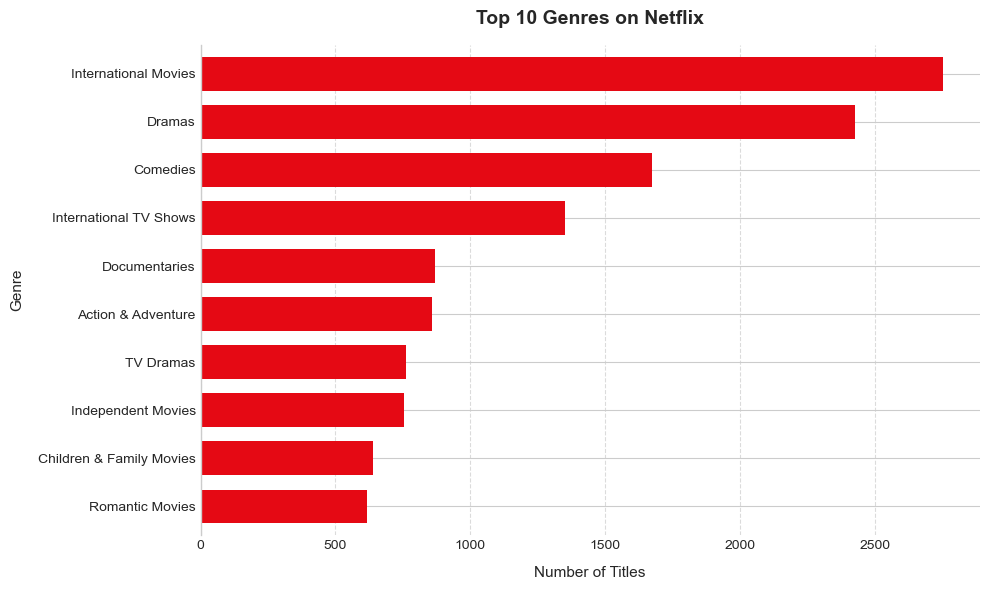

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

genres = df['listed_in'].dropna().str.split(', ').explode()
top_genres = genres.value_counts().head(10).sort_values(ascending=True)

top_genres.plot(kind='barh', color='#E50914', width=0.7, ax=ax)

ax.set_title("Top 10 Genres on Netflix", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Number of Titles", fontsize=11, labelpad=10)
ax.set_ylabel("Genre", fontsize=11, labelpad=10)
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.tight_layout()
path = 'python/top10genres.png' if os.path.exists('python') else 'top10genres.png'
plt.savefig(path, dpi=300, bbox_inches='tight')
plt.show()

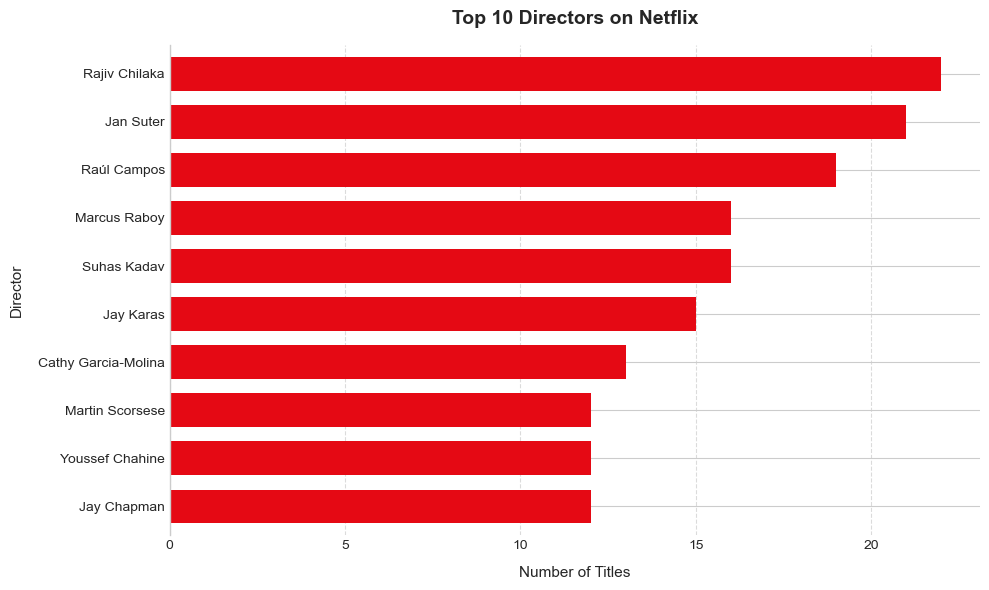

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

directors = df['director'].dropna().str.split(', ').explode()
top_directors = directors.value_counts().head(10).sort_values(ascending=True)

top_directors.plot(kind='barh', color='#E50914', width=0.7, ax=ax)

ax.set_title("Top 10 Directors on Netflix", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Number of Titles", fontsize=11, labelpad=10)
ax.set_ylabel("Director", fontsize=11, labelpad=10)
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.tight_layout()
path = 'python/Top10directors.png' if os.path.exists('python') else 'Top10directors.png'
plt.savefig(path, dpi=300, bbox_inches='tight')
plt.show()

Rajiv Chilaka is the most frequent director in the dataset, followed by Jan Suter and Raul Campos, when listing individual director credits.

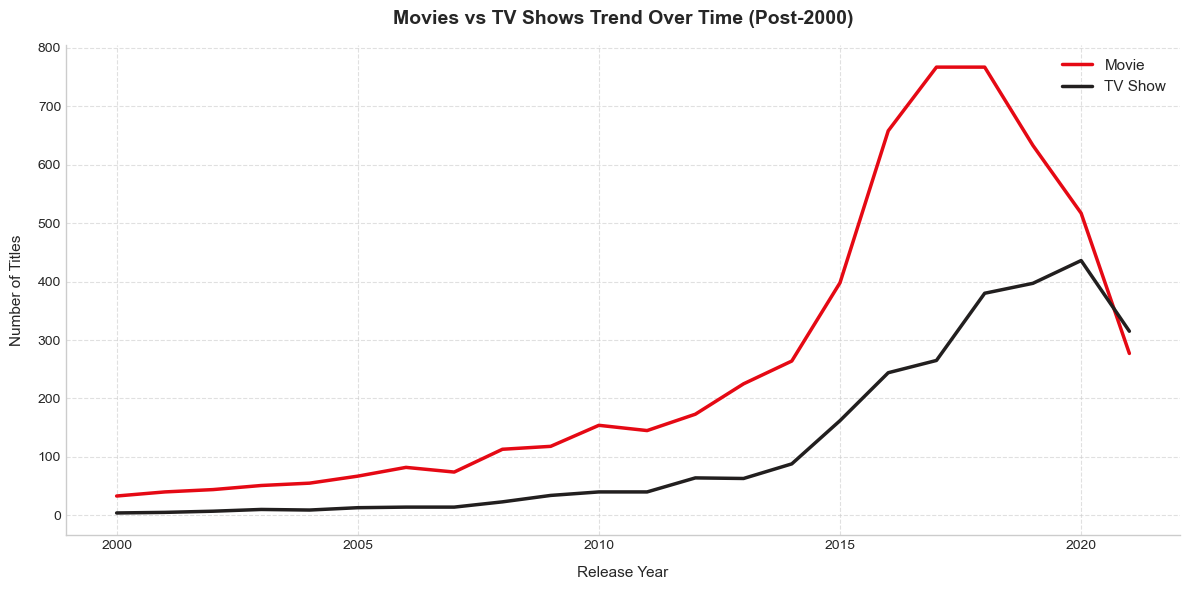

In [19]:
# Content Type Trend over Time (Post-2000 for better visibility)
recent_df = df[df['release_year'] >= 2000]
mv_trend = pd.crosstab(recent_df['release_year'], recent_df['type'])

fig, ax = plt.subplots(figsize=(12, 6))
mv_trend.plot(color=['#E50914', '#221F1F'], linewidth=2.5, ax=ax)

ax.set_title("Movies vs TV Shows Trend Over Time (Post-2000)", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Release Year", fontsize=11, labelpad=10)
ax.set_ylabel("Number of Titles", fontsize=11, labelpad=10)
ax.grid(True, linestyle='--', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(["Movie", "TV Show"], fontsize=11)

plt.tight_layout()
plt.show()

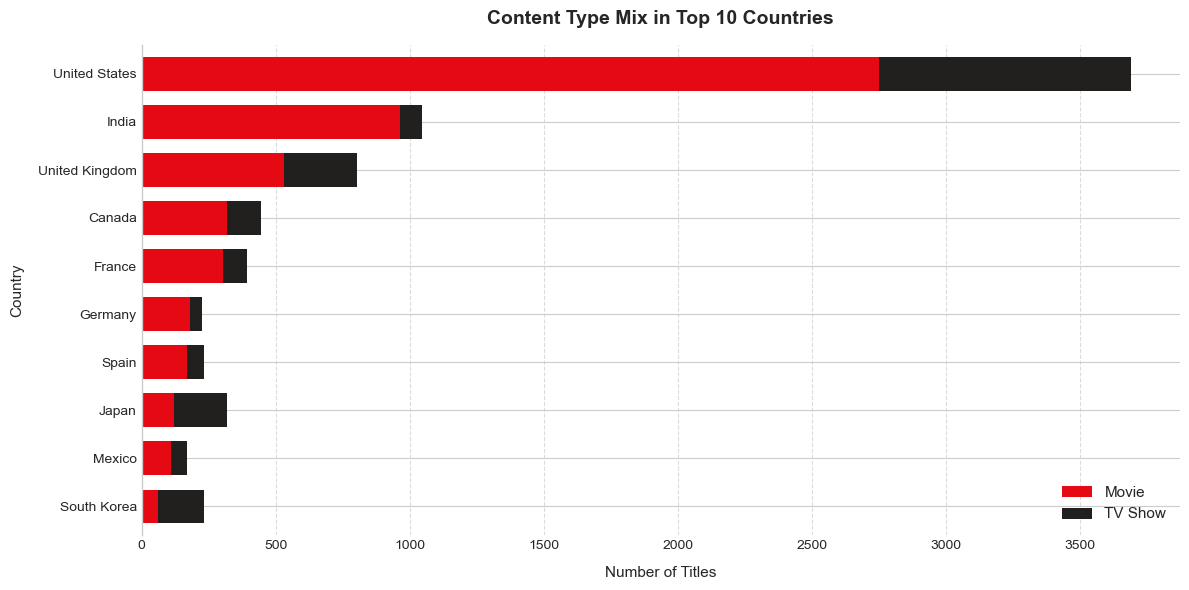

In [20]:
# Split countries and count by content type
df_country = df[['country', 'type']].dropna()
df_country['country'] = df_country['country'].str.split(', ')
df_country = df_country.explode('country')

# Filter to top 10 countries overall
top10_countries = df_country['country'].value_counts().head(10).index
df_top_countries = df_country[df_country['country'].isin(top10_countries)]

country_type = pd.crosstab(df_top_countries['country'], df_top_countries['type'])
country_type = country_type.loc[top10_countries].sort_values(by='Movie', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
country_type.plot(kind='barh', stacked=True, color=['#E50914', '#221F1F'], width=0.7, ax=ax)

ax.set_title("Content Type Mix in Top 10 Countries", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Number of Titles", fontsize=11, labelpad=10)
ax.set_ylabel("Country", fontsize=11, labelpad=10)
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.legend(["Movie", "TV Show"], fontsize=11)

plt.tight_layout()
plt.show()

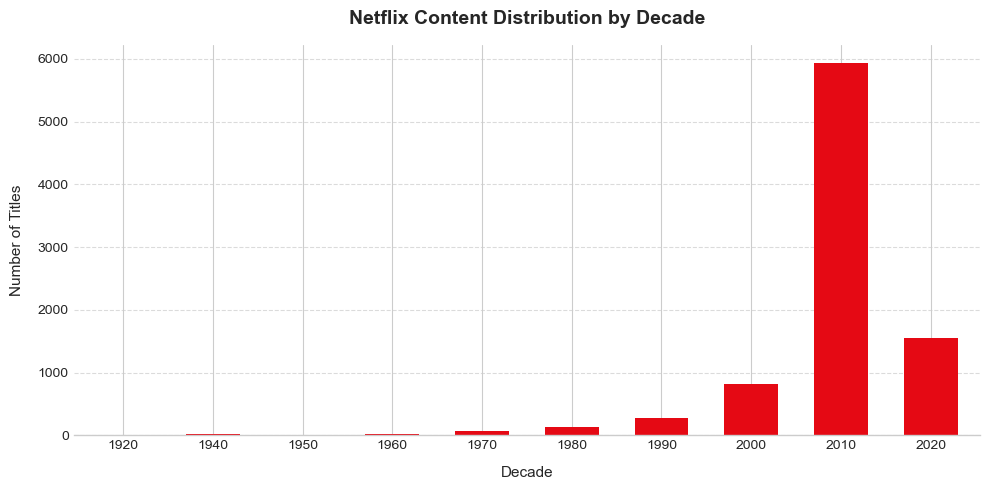

In [21]:
df['decade'] = (df['release_year'] // 10) * 10
decade_counts = df['decade'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
decade_counts.plot(kind='bar', color='#E50914', width=0.6, ax=ax)

ax.set_title("Netflix Content Distribution by Decade", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Decade", fontsize=11, labelpad=10)
ax.set_ylabel("Number of Titles", fontsize=11, labelpad=10)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

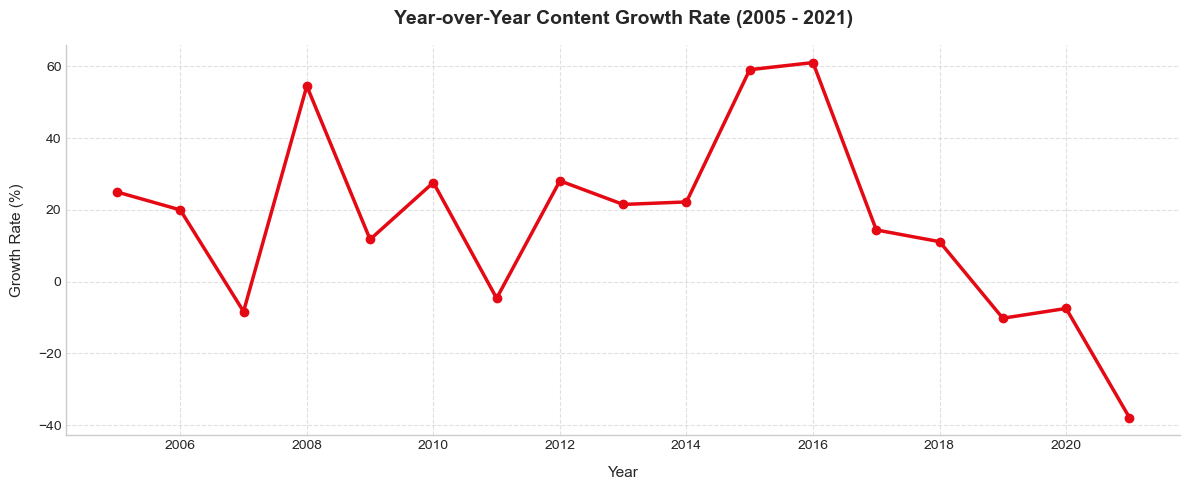

In [22]:
yearly = df['release_year'].value_counts().sort_index()
growth = yearly.pct_change() * 100

# Filter for recent years to avoid large early swings
recent_growth = growth.loc[2005:2021]

fig, ax = plt.subplots(figsize=(12, 5))
recent_growth.plot(kind='line', color='#E50914', linewidth=2.5, marker='o', ax=ax)

ax.set_title("Year-over-Year Content Growth Rate (2005 - 2021)", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Year", fontsize=11, labelpad=10)
ax.set_ylabel("Growth Rate (%)", fontsize=11, labelpad=10)
ax.grid(True, linestyle='--', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Key Insights from Exploratory Data Analysis (EDA)

- **Content Format Preference**: Movies make up approximately 70% of the Netflix catalog, outnumbering TV Shows 2.3 to 1.
- **Top Geographic Markets**: The United States is the primary content provider, followed by India and the United Kingdom.
- **Content Ratings**: TV-MA and TV-14 ratings are the most common, indicating that the majority of Netflix's catalog is targeted towards mature audiences.
- **Rapid Catalog Growth**: The platform saw exponential growth in new releases starting around 2015, peaking around 2018-2019 before stabilizing.
- **Genre Distribution**: International Movies, Dramas, and Comedies are the most frequent genres.
- **Missing Data**: While the dataset is clean of duplicates, director information is missing for a significant portion of titles, which is a common characteristic of scraped metadata.